In [20]:
# 1. Load Data

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentiment = pd.read_csv("fear_greed.csv")
trades = pd.read_csv("trader_data.csv")

print(sentiment.shape)
print(trades.shape)

(2644, 4)
(211224, 16)


In [21]:
# 2. Basic Cleaning

# Clean column names
sentiment.columns = sentiment.columns.str.strip()
trades.columns = trades.columns.str.strip()

# Missing values
print(sentiment.isnull().sum())
print(trades.isnull().sum())

# Duplicates
print(sentiment.duplicated().sum())
print(trades.duplicated().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
0
0


In [22]:
# 3. Date Conversion

# Sentiment → use date column directly
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Trades → use Timestamp (milliseconds)
trades['datetime'] = pd.to_datetime(trades['Timestamp'], unit='ms')

# Convert to date
trades['date'] = trades['datetime'].dt.date
sentiment['date'] = sentiment['date'].dt.date

# Rename classification
sentiment.rename(columns={'classification': 'Classification'}, inplace=True)

print(sentiment.head())
print(trades.head())

    timestamp  value Classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [23]:
# 4. Merge

merged = pd.merge(
    trades,
    sentiment[['date', 'Classification']],
    on='date',
    how='inner'
)

print("Merged Shape:", merged.shape)
print(merged['Classification'].value_counts())

Merged Shape: (184263, 19)
Classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64


In [28]:
# 5. Feature Engineering

merged['win'] = merged['Closed PnL'] > 0

# Encode sentiment
merged['sentiment'] = merged['Classification'].map({'Fear':0, 'Greed':1})

# Normalize side
merged['Side'] = merged['Side'].astype(str).str.lower()

# Encode side (robust)
merged['side_encoded'] = merged['Side'].apply(
    lambda x: 1 if 'buy' in x or 'long' in x else (
        0 if 'sell' in x or 'short' in x else None
    )
)

X = merged[['sentiment', 'Size USD', 'side_encoded']]
y = merged['win']

# Drop NA
data = pd.concat([X, y], axis=1).dropna()

X = data[['sentiment', 'Size USD', 'side_encoded']]
y = data['win']

print("Final dataset size:", X.shape)

Final dataset size: (170160, 3)


In [29]:
# 6. Draw Down

daily_pnl = merged.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

daily_pnl['cum_pnl'] = daily_pnl.groupby('Account')['Closed PnL'].cumsum()
daily_pnl['rolling_max'] = daily_pnl.groupby('Account')['cum_pnl'].cummax()
daily_pnl['drawdown'] = daily_pnl['cum_pnl'] - daily_pnl['rolling_max']

print(daily_pnl.head())

                                      Account        date    Closed PnL  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27 -3.275059e+05   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19  1.927736e+06   
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27  2.060745e+04   
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19  1.709873e+04   
4  0x271b280974205ca63b716753467d5a371de622ab  2024-07-03 -1.000000e+00   

        cum_pnl   rolling_max  drawdown  
0 -3.275059e+05 -3.275059e+05       0.0  
1  1.600230e+06  1.600230e+06       0.0  
2  2.060745e+04  2.060745e+04       0.0  
3  3.770617e+04  3.770617e+04       0.0  
4 -1.000000e+00 -1.000000e+00       0.0  


In [30]:
# 7. Key Metrics

# PnL
pnl_by_sentiment = merged.groupby('Classification')['Closed PnL'].agg(['mean','sum','count'])
print(pnl_by_sentiment)

# Win rate
win_rate = merged.groupby('Classification')['win'].mean()
print(win_rate)

# Avg trade size
avg_trade_size = merged.groupby('Classification')['Size USD'].mean()
print(avg_trade_size)

                     mean           sum   count
Classification                                 
Extreme Greed   25.418772  1.769655e+05    6962
Fear            50.047622  6.699925e+06  133871
Greed           87.894859  3.189617e+06   36289
Neutral         22.229713  1.587424e+05    7141
Classification
Extreme Greed    0.490089
Fear             0.415146
Greed            0.446471
Neutral          0.317182
Name: win, dtype: float64
Classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64


In [31]:
# 8. Long / Short

long_short = pd.crosstab(merged['Classification'], merged['Side'], normalize='index')
print(long_short)

Side                 buy      sell
Classification                    
Extreme Greed   0.484200  0.515800
Fear            0.493617  0.506383
Greed           0.424950  0.575050
Neutral         0.490828  0.509172


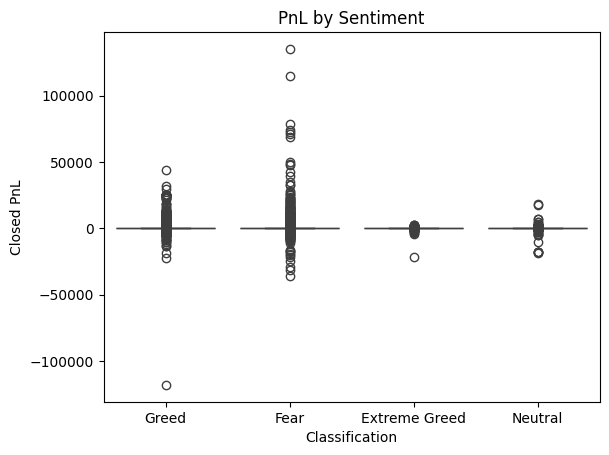

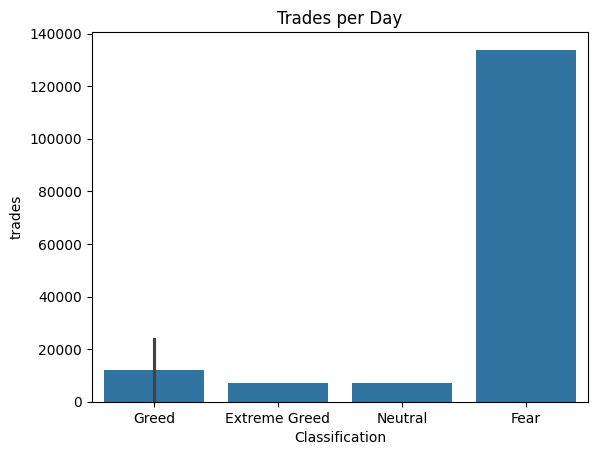

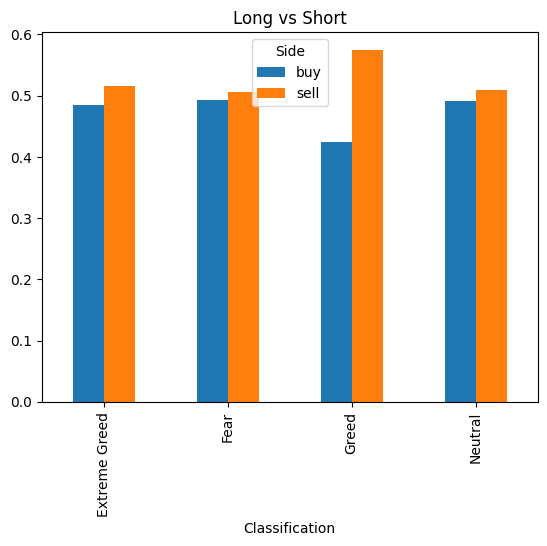

In [32]:
# 9. Visualizations

# PnL distribution
plt.figure()
sns.boxplot(x='Classification', y='Closed PnL', data=merged)
plt.title('PnL by Sentiment')
plt.show()

# Trades per day
trades_per_day = merged.groupby(['date','Classification']).size().reset_index(name='trades')

plt.figure()
sns.barplot(x='Classification', y='trades', data=trades_per_day)
plt.title('Trades per Day')
plt.show()

# Long/Short
long_short.plot(kind='bar')
plt.title('Long vs Short')
plt.show()

In [34]:
# 10. Segment Analysis

# Frequent traders
trade_counts = merged['Account'].value_counts()

frequent_accounts = trade_counts[trade_counts > trade_counts.median()].index

merged['freq_segment'] = merged['Account'].isin(frequent_accounts)

# Winner segment
total_pnl = merged.groupby('Account')['Closed PnL'].sum()

winning_accounts = total_pnl[total_pnl > 0].index

merged['winner'] = merged['Account'].isin(winning_accounts)

# Frequent vs others
freq_perf = merged.groupby(['freq_segment','Classification'])['Closed PnL'].mean().unstack()
print(freq_perf)

# Winners vs others
winner_perf = merged.groupby(['winner','Classification'])['Closed PnL'].mean().unstack()
print(winner_perf)

Classification  Extreme Greed       Fear      Greed     Neutral
freq_segment                                                   
False              -48.382749  91.442580  276.73064  351.937527
True                26.658319  44.227117   71.25969    4.058759
Classification  Extreme Greed        Fear       Greed    Neutral
winner                                                          
False             -206.074672 -170.056381  229.772491   2.696935
True                26.320044   50.622930   87.262599  22.451016


In [35]:
# 11. Model Training

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.6576163610719323

Classification Report:
               precision    recall  f1-score   support

       False       0.75      0.62      0.68     19730
        True       0.57      0.71      0.64     14302

    accuracy                           0.66     34032
   macro avg       0.66      0.67      0.66     34032
weighted avg       0.68      0.66      0.66     34032

